<h1 align="center"><b>Regression(Yield Predictor)</b></h1>
<h2 align="center"> - Manju Varshikha S </h2>

LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


DATASETS OVERVIEW

In [2]:
fao_data = pd.read_csv("data/FAOSTAT_data_en_12-29-2025.csv")
crop_data = pd.read_csv("data/Crop_recommendation.csv")
print("\nFAOSTAT Dataset:")
fao_data


FAOSTAT Dataset:


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,5.692710e+05,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,4.303000e+02,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,t,2.449430e+05,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,ha,5.470280e+05,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,kg/ha,2.968000e+02,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [3]:
fao_data.shape

(5691, 15)

In [4]:
fao_data.describe()

,Area Code (M49),Element Code,Item Code (CPC),Year Code,Year,Value
count,5691.0,5691.000000,5691.000000,5691.000000,5691.000000,5.485000e+03
mean,356.0,5411.875242,1328.012695,2011.943068,2011.943068,4.800424e+06
std,0.0,81.727538,445.286554,6.617460,6.617460,2.567830e+07
min,356.0,5312.000000,111.000000,2001.000000,2001.000000,1.635000e+02
25%,356.0,5312.000000,1242.000000,2006.000000,2006.000000,8.075000e+03
50%,356.0,5412.000000,1345.000000,2012.000000,2012.000000,1.741000e+05
75%,356.0,5510.000000,1620.000000,2018.000000,2018.000000,1.477800e+06
max,356.0,5510.000000,1970.000000,2023.000000,2023.000000,4.905334e+08


In [5]:
print("\nCrop Dataset:")
crop_data


Crop Dataset:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [6]:
crop_data.shape

(2200, 8)

In [7]:
crop_data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
fao_data['Item'].unique()[:40]
for i in fao_data['Item'].unique():
    print(i)

Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw
Apples
Apricots
Areca nuts
Bananas
Barley
Beans, dry
Cabbages
Cantaloupes and other melons
Carrots and turnips
Cashew nuts, in shell
Cassava, fresh
Castor oil seeds
Cauliflowers and broccoli
Cherries
Chick peas, dry
Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
Cocoa beans
Coconuts, in shell
Coffee, green
Coir, raw
Cucumbers and gherkins
Eggplants (aubergines)
Figs
Ginger, raw
Grapes
Green garlic
Groundnuts, excluding shelled
Jute, raw or retted
Kenaf, and other textile bast fibres, raw or retted
Lemons and limes
Lentils, dry
Lettuce and chicory
Linseed
Maize (corn)
Mangoes, guavas and mangosteens
Millet
Mushrooms and truffles
Natural rubber in primary forms
Nutmeg, mace, cardamoms, raw
Okra
Onions and shallots, dry (excluding dehydrated)
Oranges
Other beans, green
Other berries and fruits of the genus vaccinium n.e.c.
Other citrus fruit,

In [9]:
for i in crop_data['label'].unique():
    print(i)

rice
maize
chickpea
kidneybeans
pigeonpeas
mothbeans
mungbean
blackgram
lentil
pomegranate
banana
mango
grapes
watermelon
muskmelon
apple
orange
papaya
coconut
cotton
jute
coffee


CLEAN & SPLIT FAO ITEM COLUMN

In [10]:
fao_data["Item"] = fao_data["Item"].str.split(r",|and")
fao_data = fao_data.explode("Item")
fao_data

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,Anise,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,badian,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cori,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,er,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cumin,2001,2001,ha,5.692710e+05,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


STANDARDIZE CROP NAMES (MAPPING)

In [11]:
crop_mapping = {
    "Rice": "rice",
    "Maize (corn)": "maize",
    "Chick peas": "chickpea",
    "Pigeon peas": "pigeonpeas",
    "Lentils": "lentil",
    "Beans": "mothbeans",
    "Bananas": "banana",
    "Mangoes": "mango",
    "Grapes": "grapes",
    "Watermelons": "watermelon",
    "Cantaloupes ": "muskmelon",
    "Apples": "apple",
    "Oranges": "orange",
    "Papayas": "papaya",
    "Coconuts": "coconut",
    "Seed cotton": "cotton",
    "Jute": "jute",
    "Coffee": "coffee"
}
fao_data["Crop"] = fao_data["Item"].map(crop_mapping)

In [12]:
crop_data = crop_data.rename(columns={'label': 'Crop'})
crop_data

,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


Merging datasets

In [13]:
merged_data = crop_data.merge(
    fao_data,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,4.490000e+07,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3.115800e+03,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2001,2001,t,1.399000e+08,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2002,2002,ha,4.117610e+07,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2.616300e+03,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,7.742000e+02,E,Estimated value,NaN
124196,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN
124197,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Area harvested,1610.0,Coffee,2023,2023,ha,4.378620e+05,I,Value imputed by a receiving agency,NaN
124198,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2023,2023,kg/ha,7.602000e+02,E,Estimated value,NaN


FILTERING "YIELD" ONLY

In [14]:
merged_data = merged_data[merged_data["Element"] == "Yield"]
merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3115.8,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2616.3,A,Official figure,NaN
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2003,2003,kg/ha,3117.7,A,Official figure,NaN
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2004,2004,kg/ha,2975.6,A,Official figure,NaN
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2005,2005,kg/ha,3153.7,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2019,2019,kg/ha,766.7,A,Official figure,NaN
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2020,2020,kg/ha,712.6,A,Official figure,NaN
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2021,2021,kg/ha,789.7,A,Official figure,NaN
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,774.2,E,Estimated value,NaN


In [15]:
merged_data['Crop'].value_counts()

Crop
rice          2300
maize         2300
chickpea      2300
pigeonpeas    2300
mothbeans     2300
lentil        2300
banana        2300
mango         2300
grapes        2300
watermelon    2300
muskmelon     2300
apple         2300
orange        2300
papaya        2300
coconut       2300
cotton        2300
jute          2300
coffee        2300
Name: count, dtype: int64

DROP IRRELEVANT COLUMNS

In [16]:
merged_data = merged_data.drop(columns=[
    'Domain Code','Domain','Area Code (M49)','Area',
    'Element Code','Element','Item Code (CPC)','Item',
    'Year','Year Code','Unit','Flag','Flag Description','Note'
])
merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


Missing value and duplicate checks

In [17]:
print("Missing Values:\n", merged_data.isnull().sum())

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64


In [18]:
print("\nDuplicate Rows:", merged_data.duplicated().sum())


Duplicate Rows: 500


In [19]:
merged_data = merged_data.drop_duplicates().reset_index(drop=True)
merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
40895,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
40896,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
40897,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
40898,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


Summary Statistics

In [20]:
merged_data.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000
mean,56.298411,54.352934,53.711027,25.737515,72.715920,6.457820,108.525860,10044.335697
std,37.980967,35.064486,54.663487,5.114830,20.803797,0.802157,58.311202,11885.622054
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,326.900000
25%,24.000000,28.000000,22.000000,23.089507,60.395233,6.000249,66.484904,952.300000
50%,44.000000,50.000000,35.000000,25.617074,80.525861,6.399434,97.100870,4322.300000
75%,91.000000,69.000000,52.000000,28.434307,90.458286,6.893509,145.929893,17654.100000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,44328.400000


In [21]:
merged_data.nunique()

N               136
P               117
K                73
temperature    1800
humidity       1800
ph             1800
rainfall       1800
Crop             18
Value           406
dtype: int64

OUTLIER REMOVAL USING IQR

In [22]:
numeric_cols = ["N","P","K","temperature","humidity","ph","rainfall","Value"]

Q1 = merged_data[numeric_cols].quantile(0.25)
Q3 = merged_data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

clean_data = merged_data[
    ~((merged_data[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (merged_data[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]
clean_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
40895,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
40896,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
40897,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
40898,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


In [23]:
print("Before:", merged_data.shape)
print("After :", clean_data.shape)

Before: (40900, 9)
After : (32043, 9)


In [24]:
clean_data['Crop'].value_counts()

Crop
banana        2300
lentil        2300
jute          2300
coffee        2300
coconut       2300
cotton        2300
watermelon    2300
maize         2200
muskmelon     2200
mango         2185
pigeonpeas    2116
rice          1748
orange        1701
chickpea      1449
papaya        1178
mothbeans     1166
Name: count, dtype: int64

In [25]:
clean_data.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,32043.000000,32043.000000,32043.000000,32043.000000,32043.000000,32043.000000,32043.000000,32043.000000
mean,63.352121,43.322223,34.334051,25.912920,71.878626,6.480131,109.079568,9096.586968
std,38.568947,22.548639,16.492411,3.820834,19.824505,0.684690,58.205121,11446.764375
min,0.000000,5.000000,5.000000,15.632110,15.361435,4.669108,20.211267,326.900000
25%,27.000000,24.000000,21.000000,23.793920,59.371476,6.058306,62.503519,901.000000
50%,69.000000,42.000000,31.000000,25.866324,78.046029,6.438008,97.415864,3115.800000
75%,97.000000,60.000000,47.000000,28.227767,88.071123,6.925412,154.823886,13489.100000
max,140.000000,95.000000,85.000000,36.322681,99.981876,8.204862,264.614870,42286.300000


In [26]:
clean_data.nunique()

N               136
P                91
K                62
temperature    1422
humidity       1422
ph             1422
rainfall       1422
Crop             16
Value           356
dtype: int64

In [27]:
clean_data.to_csv("final_merged_yield_1.csv", index=False)
print("Final merged dataset saved as final_merged_yield_1.csv")

Final merged dataset saved as final_merged_yield_1.csv


CORRELATION HEATMAP

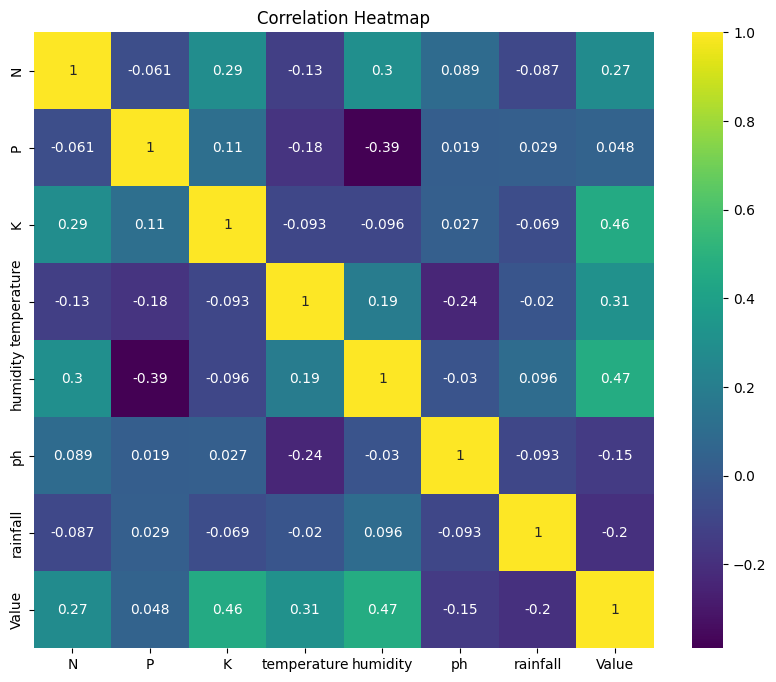

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(clean_data[numeric_cols].corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

BOXPLOT

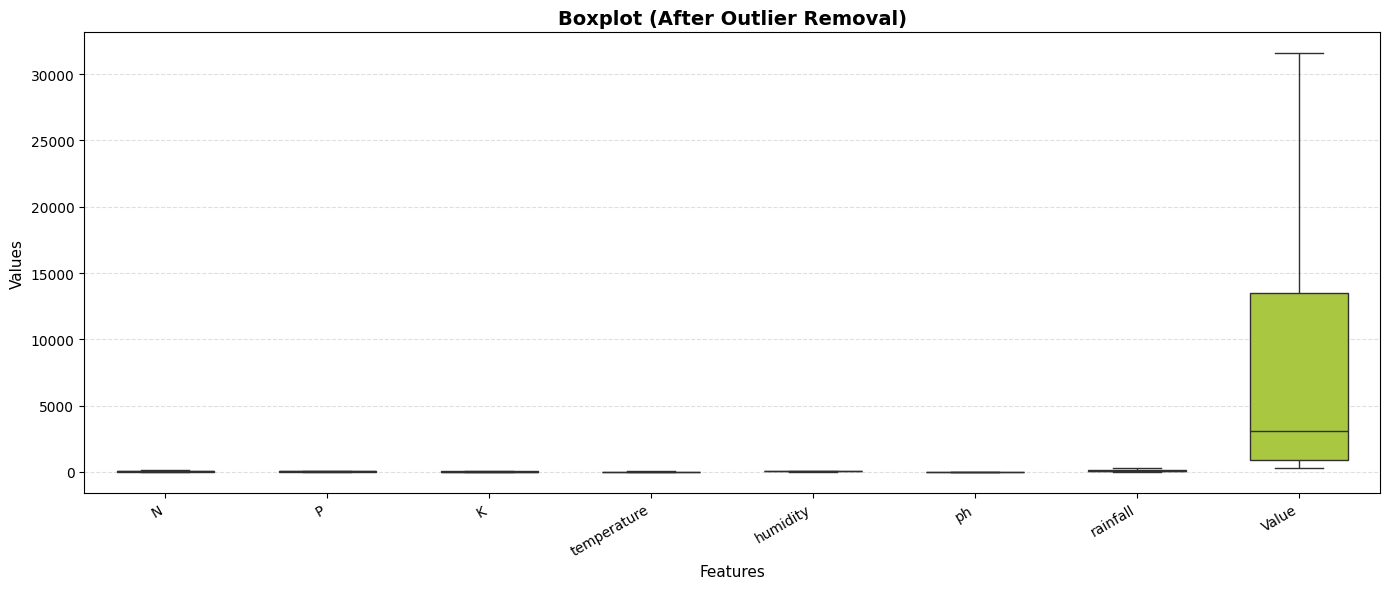

In [29]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=clean_data[numeric_cols],
    palette="viridis",
    width=0.6,
    showfliers=False   
)

plt.title("Boxplot (After Outlier Removal)", fontsize=14, fontweight="bold")
plt.xlabel("Features", fontsize=11)
plt.ylabel("Values", fontsize=11)

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


MODEL TRAINING

In [30]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [31]:
features = clean_data.drop(columns=['Value', 'Element'], errors='ignore')
target = clean_data['Value']

# One-hot encode for models
features = pd.get_dummies(features, columns=['Crop'], drop_first=False)
feature_columns = features.columns 

SCALE NUMERIC FEATURES

In [32]:
scaler = StandardScaler()
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns
features[numeric_cols] = scaler.fit_transform(features[numeric_cols])

TRAIN-TEST SPLIT

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [34]:
print(f"Train Shape : {X_train.shape}")
print(f"Test Shape  : {X_test.shape}\n")

Train Shape : (25634, 23)
Test Shape  : (6409, 23)



In [35]:
def evaluate_model(model_name, y_tr, y_tr_pred, y_te, y_te_pred):
    print(f"--- {model_name} ---")
    print(f"Train R²: {r2_score(y_tr, y_tr_pred):.4f}")
    print(f"Test R²  : {r2_score(y_te, y_te_pred):.4f}")
    print(f"MAE      : {mean_absolute_error(y_te, y_te_pred):,.2f}")
    print(f"RMSE     : {np.sqrt(mean_squared_error(y_te, y_te_pred)):,.2f}\n")

def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, c="forestgreen", alpha=0.4)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             c="darkgreen", linewidth=2)
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(title)
    plt.tight_layout()
    plt.show()

1.RIDGE REGRESSION

--- Ridge Regression ---
Train R²: 0.9642
Test R²  : 0.9668
MAE      : 1,109.73
RMSE     : 2,110.87



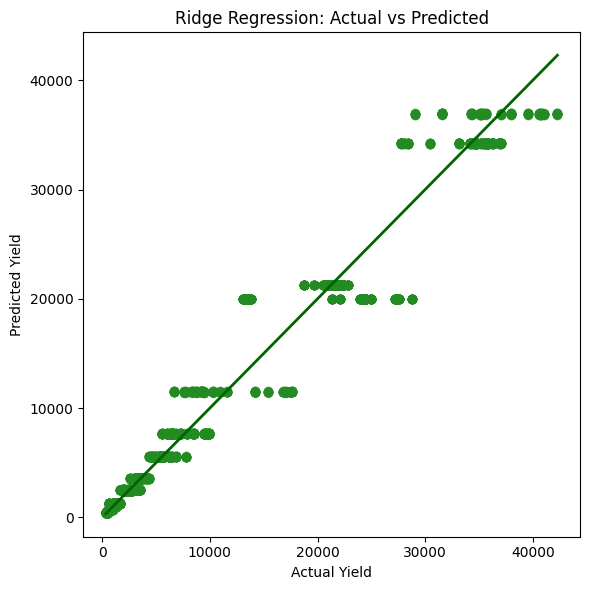

In [36]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)
evaluate_model("Ridge Regression", y_train, ridge_train_pred, y_test, ridge_test_pred)
plot_actual_vs_pred(y_test, ridge_test_pred, "Ridge Regression: Actual vs Predicted")

2A.RANDOM FOREST

--- Random Forest ---
Train R²: 0.9645
Test R²  : 0.9634
MAE      : 1,159.34
RMSE     : 2,215.83



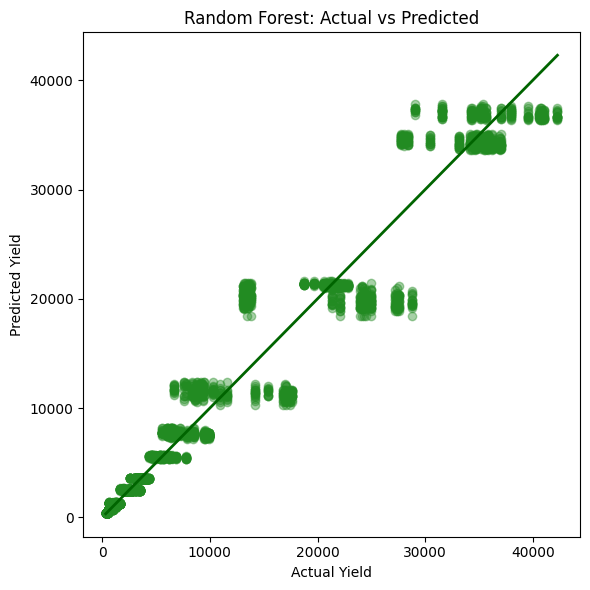

In [37]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
evaluate_model("Random Forest", y_train, rf_train_pred, y_test, rf_test_pred)
plot_actual_vs_pred(y_test, rf_test_pred, "Random Forest: Actual vs Predicted")

2B.RANDOM FOREST TUNED

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Best RF Parameters:", grid_rf.best_params_)

rf_tuned_train_pred = best_rf.predict(X_train)
rf_tuned_test_pred = best_rf.predict(X_test)
evaluate_model("Random Forest Tuned", y_train, rf_tuned_train_pred, y_test, rf_tuned_test_pred)
plot_actual_vs_pred(y_test, rf_tuned_test_pred, "Random Forest Tuned: Actual vs Predicted")

3A.XGBOOST

In [ ]:
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror",
                         random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
evaluate_model("XGBoost", y_train, xgb_train_pred, y_test, xgb_test_pred)
plot_actual_vs_pred(y_test, xgb_test_pred, "XGBoost: Actual vs Predicted")

3B.XGBOOST TUNED

In [ ]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_xgb = GridSearchCV(XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
                        param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print("Best XGBoost Parameters:", grid_xgb.best_params_)

xgb_tuned_train_pred = best_xgb.predict(X_train)
xgb_tuned_test_pred = best_xgb.predict(X_test)
evaluate_model("XGBoost Tuned", y_train, xgb_tuned_train_pred, y_test, xgb_tuned_test_pred)
plot_actual_vs_pred(y_test, xgb_tuned_test_pred, "XGBoost Tuned: Actual vs Predicted")

Overfitting / Underfitting Check

In [ ]:
train_r2_tree = [r2_score(y_train, rf_train_pred),
                 r2_score(y_train, rf_tuned_train_pred),
                 r2_score(y_train, xgb_train_pred),
                 r2_score(y_train, xgb_tuned_train_pred)]

test_r2_tree = [r2_score(y_test, rf_test_pred),
                r2_score(y_test, rf_tuned_test_pred),
                r2_score(y_test, xgb_test_pred),
                r2_score(y_test, xgb_tuned_test_pred)]

tree_models = ["RF", "RF Tuned", "XGB", "XGB Tuned"]

plt.figure(figsize=(10,6))
plt.plot(tree_models, train_r2_tree, marker='o', label="Train R²", color='forestgreen', linewidth=2)
plt.plot(tree_models, test_r2_tree, marker='o', label="Test R²", color='limegreen', linewidth=2)
plt.title("Overfitting / Underfitting Check (Tree Models)")
plt.ylabel("R² Score")
plt.legend()
plt.show()

RMSE Before vs After Hyperparameter Tuning

In [ ]:
rmse_tree = [np.sqrt(mean_squared_error(y_test, rf_test_pred)),
             np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_tuned_test_pred))]

plt.figure(figsize=(10,6))
sns.barplot(x=tree_models, y=rmse_tree, palette="Greens")
plt.title("Test RMSE Comparison for Tree-Based Models (Before vs After Tuning)")
plt.ylabel("RMSE")
plt.show()

Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest", "Random Forest Tuned",
              "XGBoost", "XGBoost Tuned"],
    "Test R2": [r2_score(y_test, ridge_test_pred),
                r2_score(y_test, rf_test_pred),
                r2_score(y_test, rf_tuned_test_pred),
                r2_score(y_test, xgb_test_pred),
                r2_score(y_test, xgb_tuned_test_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
             np.sqrt(mean_squared_error(y_test, rf_test_pred)),
             np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_tuned_test_pred))]
})

print("\nFinal Model Comparison:\n")
print(comparison_df.sort_values(by="Test R2", ascending=False))

Save / Load Best Model

In [ ]:
joblib.dump(best_xgb, "models/model_final_1.joblib")
joblib.dump(list(feature_columns), "models/columns_final_1.pkl")

print("Best XGBoost model and feature columns saved successfully!")

SAMPLE PREDICTION

In [ ]:
default_sample_r = {
    "N": 87,
    "P": 54,
    "K": 20,
    "temperature": 25.61707368,
    "humidity": 63.4711755,
    "ph": 6.576418207,
    "rainfall": 108.8303762,
    "Crop": "maize"
}

In [ ]:
default_df_r = pd.DataFrame([default_sample_r])

default_df_r = pd.get_dummies(default_df_r, columns=["Crop"])

for col in feature_cols:
    if col not in default_df_r.columns:
        default_df_r[col] = 0

default_df_r = default_df_r[feature_cols]


In [ ]:
predicted_yield = yield_model.predict(default_df_r)[0]

print("===== DEFAULT SAMPLE PREDICTION (R) =====")
print("Crop:", default_sample_r["Crop"])
print(f"Predicted Yield: {predicted_yield:,.2f} kg")
print("Actual Yield: (from dataset)")
